<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>DBSCAN vs K-Means</b>
</h1>
<div style="font-family:'Times New Roman';">
<b>Goal:</b>
<ol>
<li>Compare DBSCAN and K-Means on the same datasets</li>
<li>See where K-Means fails on non convex shapes</li>
<li>See how DBSCAN handles shapes and noise</li>
<li>Understand which one to pick when</li>
</ol>
Both DBSCAN and K-Means do clustering but they think very differently. K-Means draws straight ish boundaries around centers, DBSCAN follows density. The easiest way to feel the difference is to run them on shapes that are not round and just look at the plots.
</div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, make_circles
from sklearn.cluster import KMeans, DBSCAN

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Two tricky datasets</b>
</h2>
<div style="font-family:'Times New Roman';">
Let me make two datasets that are famous for breaking K-Means, the two moons and two circles. Both have clusters that are clearly there for our eyes but are not round blobs.
</div>

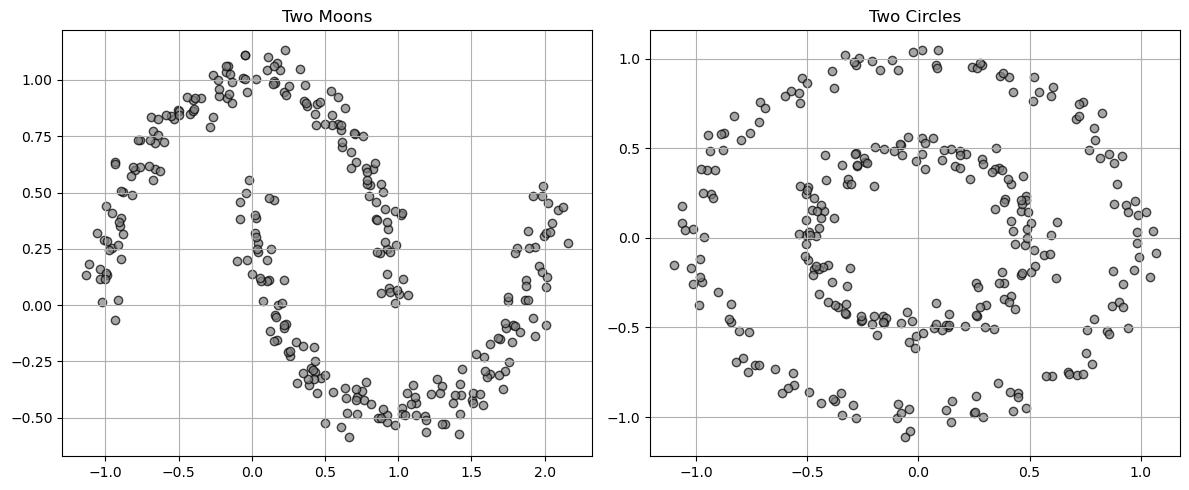

In [2]:
np.random.seed(42)

X_moons, _ = make_moons(n_samples=300, noise=0.06, random_state=42)
X_circles, _ = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_moons[:, 0], X_moons[:, 1], color='gray', edgecolors='k', alpha=0.7)
axes[0].set_title("Two Moons")
axes[0].grid(True)
axes[1].scatter(X_circles[:, 0], X_circles[:, 1], color='gray', edgecolors='k', alpha=0.7)
axes[1].set_title("Two Circles")
axes[1].grid(True)
plt.tight_layout()
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Why K-Means struggles here</b>
</h2>
<div style="font-family:'Times New Roman';">
K-Means puts each point with the nearest center, which basically cuts the space with straight boundaries. That works great for round blobs but on a moon or a ring the nearest center is often on the wrong arm or the wrong ring. So K-Means slices these shapes in a way that looks clearly wrong to us.
</div>

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>A small helper to plot clusters</b>
</h2>
<div style="font-family:'Times New Roman';">
Just a tiny function so i do not repeat the same plotting code again and again. Noise points (label -1) are drawn as black crosses.
</div>

In [3]:
def plot_clusters(ax, X, labels, title):
    for lab in sorted(set(labels)):
        mask = labels == lab
        if lab == -1:
            ax.scatter(X[mask, 0], X[mask, 1], c='black', marker='x', label='Noise')
        else:
            ax.scatter(X[mask, 0], X[mask, 1], edgecolors='k', alpha=0.7, label=f'Cluster {lab}')
    ax.set_title(title)
    ax.grid(True)

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Running both on every dataset</b>
</h2>
<div style="font-family:'Times New Roman';">
Now lets run K-Means (with k=2) and DBSCAN on both datasets and put the plots in a grid. Top row is the moons, bottom row is the circles. Left column is K-Means, right column is DBSCAN.
</div>

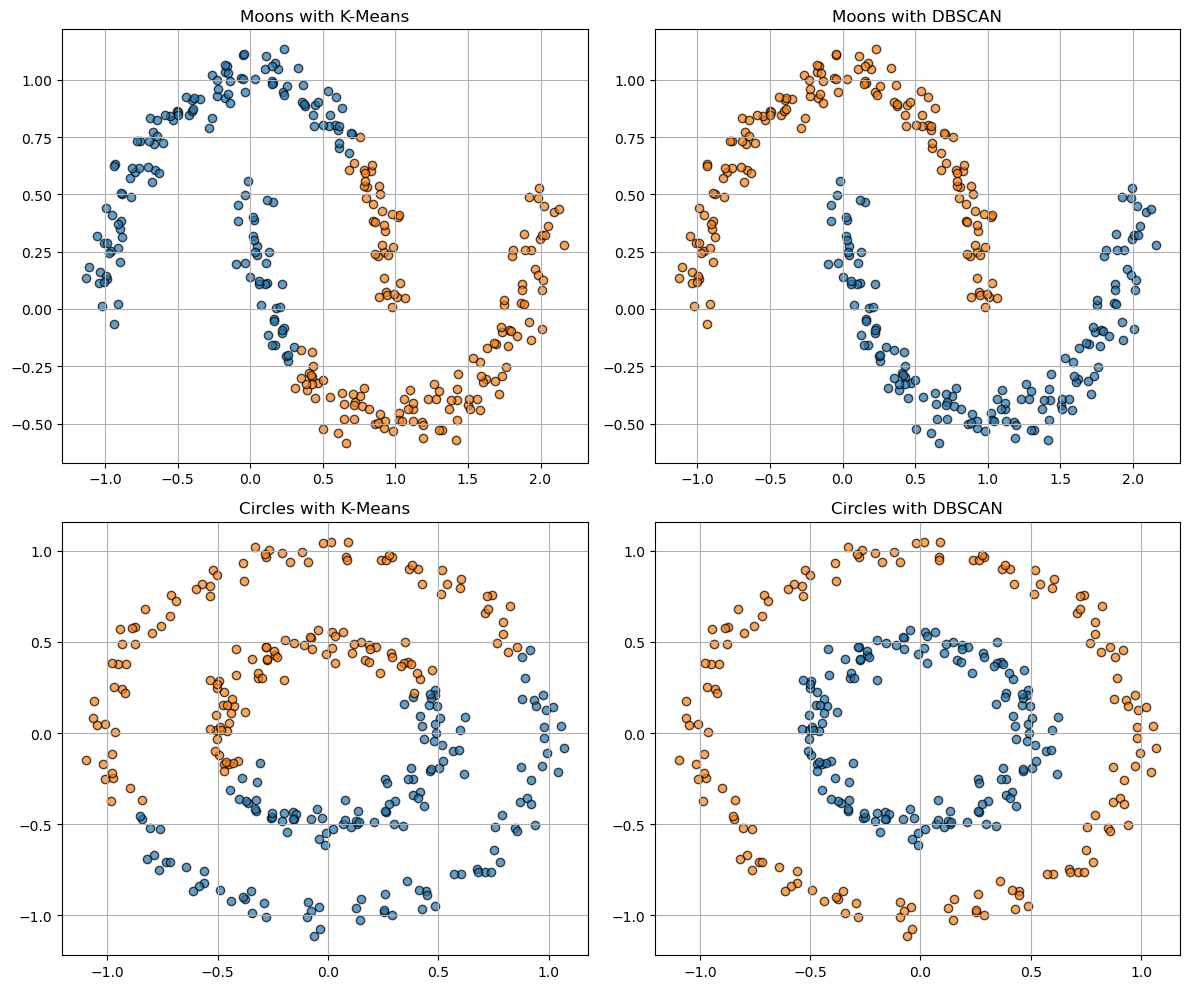

In [4]:
# each dataset comes with its own eps that works well for it
datasets = [
    ("Moons", X_moons, 0.2),
    ("Circles", X_circles, 0.2),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for row, (name, data, eps) in enumerate(datasets):
    # K-Means with 2 clusters
    km_labels = KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(data)
    plot_clusters(axes[row, 0], data, km_labels, f"{name} with K-Means")

    # DBSCAN
    db_labels = DBSCAN(eps=eps, min_samples=5).fit_predict(data)
    plot_clusters(axes[row, 1], data, db_labels, f"{name} with DBSCAN")

plt.tight_layout()
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>So what is the actual difference?</b>
</h2>
<div style="font-family:'Times New Roman';">
Putting it all together.
<ul>
<li>K-Means needs you to pick k, DBSCAN figures out the number of clusters by itself.</li>
<li>K-Means assumes round blobs, DBSCAN handles any shape.</li>
<li>K-Means forces every point into a cluster, DBSCAN can mark outliers as noise.</li>
<li>K-Means is usually faster and works fine in higher dimensions, DBSCAN gets tricky there and is sensitive to eps.</li>
<li>K-Means works better when clusters are round and roughly equal in size, DBSCAN works better for weird shapes and when there is noise.</li>
</ul>
</div>

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Summary</b>
</h2>
<div style="font-family:'Times New Roman';">
<ul>
<li>Saw K-Means cut the moons and circles in a clearly wrong way because it only draws straight boundaries around centers</li>
<li>Saw DBSCAN follow the actual shapes and separate the two moons and two rings correctly</li>
<li>DBSCAN also marked some thin outlier points as noise</li>
<li>K-Means is still great for round, similar sized clusters and bigger or higher dimensional data</li>
<li>Pick the algorithm based on the shape of your data and whether you care about outliers</li>
</ul>
That wraps up DBSCAN, from the intuition, to building it from scratch, to comparing it with K-Means.
</div>